In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import os.path as op

In [3]:
"""
Aggregate 4 cell-type comparison TSV files into one matrix and plot a heatmap.

Each TSV is expected to look like:

    celltype_semi_manual    B cell    CD14 monocyte    CD4 T cell    ...
    DC                      0         159              6             ...
    B cell                  122       17               0             ...
    ...

i.e. the first column is the row label (e.g. manually annotated cell type)
and the remaining columns are counts against another labeling scheme
(e.g. automated/predicted cell type).

Usage:
    python aggregate_celltype_heatmap.py file1.tsv file2.tsv file3.tsv file4.tsv \
        --outdir /mnt/user-data/outputs --normalize row
"""

import argparse
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def load_matrix(path: str) -> pd.DataFrame:
    """Load one TSV into a DataFrame indexed by the first column."""
    df = pd.read_csv(path, sep="\t", index_col=0)
    df.index.name = "row_label"
    df.columns.name = "col_label"
    # Make sure everything is numeric (coerce, then fill any bad parses with 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0)
    return df


def aggregate_matrices(dfs: list[pd.DataFrame]) -> pd.DataFrame:
    """
    Sum a list of (possibly differently-shaped) matrices, aligning on the
    union of row and column labels. Missing entries are treated as 0.
    """
    all_rows = sorted(set().union(*[set(d.index) for d in dfs]))
    all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))

    aligned = [
        d.reindex(index=all_rows, columns=all_cols, fill_value=0) for d in dfs
    ]

    total = aligned[0].copy()
    for d in aligned[1:]:
        total = total.add(d, fill_value=0)

    return total.astype(int)


def normalize_matrix(df: pd.DataFrame, how: str | None) -> pd.DataFrame:
    """Optionally normalize counts to proportions."""
    if how is None or how == "none":
        return df
    if how == "row":
        return df.div(df.sum(axis=1).replace(0, 1), axis=0)
    if how == "col":
        return df.div(df.sum(axis=0).replace(0, 1), axis=1)
    if how == "all":
        return df / df.values.sum()
    raise ValueError(f"Unknown normalization: {how}")


def plot_heatmap(df: pd.DataFrame, out_path: Path, normalize: str | None, title: str):
    plt.figure(figsize=(1.0 * df.shape[1] + 3, 0.6 * df.shape[0] + 3))

    fmt = ".0f" if normalize in (None, "none") else ".2f"
    cmap = "viridis" if normalize in (None, "none") else "magma"

    ax = sns.heatmap(
        df,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "count" if normalize in (None, "none") else "proportion"},
    )
    ax.set_xlabel("Predicted / comparison label")
    ax.set_ylabel("Manual / reference label")
    ax.set_title(title)
    plt.tight_layout()
    #plt.savefig(out_path, dpi=200)
    #plt.close()
    print(f"Saved heatmap to {out_path}")



In [4]:
celltype1 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep2-kallisto-cellbender-markers/celltype_rw_crosstab.tsv')
celltype2 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-markers/celltype_rw_crosstab.tsv')
celltype3 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep1-markers/celltype_rw_crosstab.tsv')
celltype4 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-markers/celltype_rw_crosstab.tsv')
agg = aggregate_matrices([celltype1, celltype2, celltype3, celltype4])
agg = agg.drop(index='Megakaryocytes', columns='Megakaryocytes', errors='ignore')
agg = normalize_matrix(agg, 'col')

In [5]:

experiment_name = 'bd-rhap-rep2-markers'
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"
grn_adata3 =  sc.read_h5ad(op.join(analysis_output_dir, 'bd-rhap-rep2-markers_processed.h5ad'))


In [6]:
# %%
import pandas as pd
import numpy as np
import scanpy as sc
import scipy.sparse as scs
import seaborn as sns
import matplotlib.pyplot as plt

runtimes = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/runtimes_repeat_data.tsv')
runtimes['short_name'] = runtimes['experiment'].map({'10x-rep1-kallisto-cellbender-X': '10x-1', 'bd-rhap-rep2-X': 'BD-2'})

score_df = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/clustering_scores_data_file.tsv', sep='\t')
score_df['short_name'] = score_df['category'].map({'within- \ndataset-10x': '10x-1', 'within- \ndataset-bd': 'BD-2', 'cross-  \ndataset': 'cross-  \ndataset'})

markers = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/jaccard_marker_overlap_combined.tsv', sep='\t')

col_names = {'off target': 'Off-target', 'on target': 'On-target'}
markers['is_mapped_hr'] = markers['is_mapped'].map(col_names)

pal = {
    'CD14+ Mono': (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
    'CD14- Mono': (0.6509803921568628, 0.807843137254902, 0.8901960784313725),
    'CD4+ T cell': (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
    'CD8+ T cell': (0.984313725490196, 0.6039215686274509, 0.6),
    'B cell': (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
    'NK cell': (1.0, 0.4980392156862745, 0.0),
    'pDC': (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
    'DC': (0.2, 0.6274509803921569, 0.17254901960784313),
}

acronyms = {
    'CD14+ Mono': 'M+',
    'CD14- Mono': 'M-',
    'CD4+ T cell': 'T4',
    'CD8+ T cell': 'T8',
    'B cell': 'BC',
    'NK cell': 'NK',
    'pDC': 'pD',
    'DC': 'DC',
}


In [7]:
import string
import math

/tmp/ipykernel_626976/2999462346.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=runtimes, x='short_name', y='time_min', palette='Set2', legend=False, ax=ax_runtime)
/tmp/ipykernel_626976/2999462346.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_626976/2999462346.py:174: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
/tmp/ipykernel_626976/2999462346.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Ass

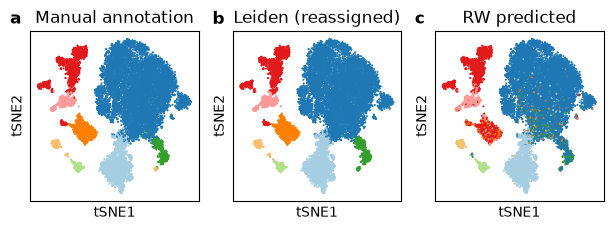

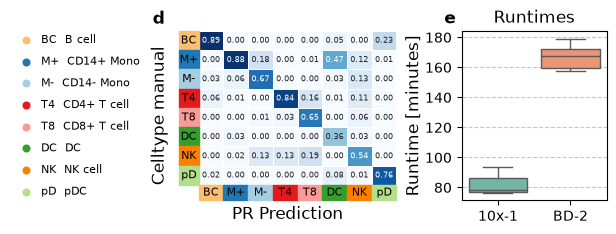

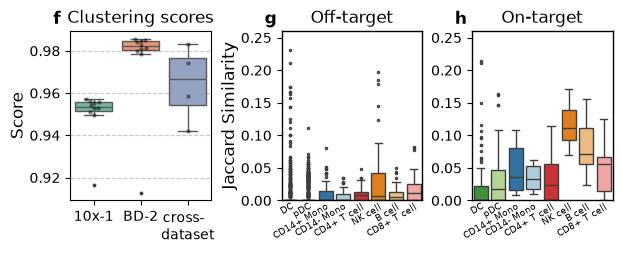

In [17]:
import string
letters = iter(string.ascii_lowercase)

def label_panel(ax, letter):
    ax.text(
        -0.12, 1.12, letter,
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left',
    )

# =========================================================
# Figure 1 (A, B, C): qualitative tSNE plots
# =========================================================
fig1, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(7.4, 2.2))
fig1.subplots_adjust(wspace=0.2)

sc.pl.tsne(
    grn_adata3, color='celltype_semi_manual', palette=pal,
    ax=ax0, show=False, title='Manual annotation',
)
ax0.set_aspect('auto')
handles, labels = ax0.get_legend_handles_labels()
labels = [f"{acronyms.get(l, '??')}  {l}" for l in labels]
ax0.get_legend().remove()

sc.pl.tsne(
    grn_adata3, color='leiden_remap', palette=pal,
    ax=ax1, show=False, legend_loc=None, title='Leiden (reassigned)',
)
ax1.set_aspect('auto')

sc.pl.tsne(
    grn_adata3, color='celltype_rw_pred', palette=pal,
    ax=ax2, show=False, legend_loc=None, title='RW predicted',
)
ax2.set_aspect('auto')

for ax in (ax0, ax1, ax2):
    label_panel(ax, next(letters))

fig1.savefig(
    '/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/figure3_tsne.pdf',
    dpi=300, bbox_inches='tight', pad_inches=0.03,
)

# =========================================================
# Figure 2 (D, E): legend (unlabeled) + heatmap + runtimes
# =========================================================
fig2 = plt.figure(figsize=(7.3, 2.2))
gs2 = fig2.add_gridspec(1, 3, width_ratios=[1, 3, 2], wspace=0.45)
ax_legend = fig2.add_subplot(gs2[0])
ax_heat = fig2.add_subplot(gs2[1])
ax_runtime = fig2.add_subplot(gs2[2])

ax_legend.axis('off')
ax_legend.legend(
    handles, labels,
    loc='center',
    frameon=False,
    ncol=1,
    fontsize=8,
    handletextpad=0.4,
    labelspacing=0.9,
    markerscale=0.8,
    borderaxespad=0,
)

sns.heatmap(
    agg,
    annot=True,
    annot_kws={'fontsize': 6},
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    fmt=".2f",
    ax=ax_heat,
    cbar=False,
    xticklabels=False,
    yticklabels=False,
)
ax_heat.set_xlabel("PR Prediction", fontsize=12)
ax_heat.set_ylabel("Celltype manual", fontsize=12, labelpad=8)

n_rows, n_cols = agg.shape
bar_frac = 0.10

for j, col_label in enumerate(agg.columns):
    color = pal.get(col_label, 'grey')
    ax_heat.add_patch(plt.Rectangle(
        (j, n_rows), 1, n_rows * bar_frac,
        color=color, clip_on=False, transform=ax_heat.transData,
    ))
    ax_heat.text(
        j + 0.5, n_rows + n_rows * bar_frac / 2, acronyms.get(col_label, '??'),
        ha='center', va='center', fontsize=8, clip_on=False,
    )

for i, row_label in enumerate(agg.index):
    color = pal.get(row_label, 'grey')
    ax_heat.add_patch(plt.Rectangle(
        (-n_cols * bar_frac, i), n_cols * bar_frac, 1,
        color=color, clip_on=False, transform=ax_heat.transData,
    ))
    ax_heat.text(
        -n_cols * bar_frac / 2, i + 0.5, acronyms.get(row_label, '??'),
        ha='center', va='center', fontsize=8, clip_on=False,
    )

ax_heat.set_xlim(-n_cols * bar_frac, n_cols)
ax_heat.set_ylim(n_rows + n_rows * bar_frac, 0)

sns.boxplot(data=runtimes, x='short_name', y='time_min', palette='Set2', legend=False, ax=ax_runtime)
ax_runtime.set_title('Runtimes')
ax_runtime.set_ylabel('Runtime [minutes]', labelpad=2, fontsize=12)
ax_runtime.set_xlabel('')
ax_runtime.tick_params(axis='x', labelsize=10)
ax_runtime.grid(axis='y', linestyle='--', alpha=0.7)

for ax in (ax_heat, ax_runtime):
    label_panel(ax, next(letters))

fig2.savefig(
    '/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/figure3_heatmap.pdf',
    dpi=300, bbox_inches='tight', pad_inches=0.03,
)
# =========================================================
# Figure 3 (F, G, H): score boxplot + jaccard off/on-target
# =========================================================
cat_order = ['10x-1', 'BD-2', 'cross-  \ndataset']
fig3 = plt.figure(figsize=(7, 2.2))

# outer: (score + off-target) block vs on-target — width_ratios=[2,1] keeps
# each of the three panels the same width as before, since the left block
# holds two panels and the right block holds one.
outer_gs3 = fig3.add_gridspec(1, 2, width_ratios=[2.5, 1], wspace=0.2)

# gap between ax_score and ax_off, independent of the outer gap
left_gs3 = outer_gs3[0].subgridspec(1, 2, wspace=0.5)

ax_score = fig3.add_subplot(left_gs3[0])
ax_off = fig3.add_subplot(left_gs3[1])
ax_on = fig3.add_subplot(outer_gs3[1])

sns.boxplot(
    data=score_df, x='short_name', y='score', hue='short_name',
    order=cat_order, hue_order=cat_order,
    palette='Set2', legend=False, dodge=False, fliersize=1, ax=ax_score,
)
sns.swarmplot(
    data=score_df, x='short_name', y='score', order=cat_order,
    color='black', alpha=0.5, size=3, ax=ax_score,
)
ax_score.set_title('Clustering scores')
ax_score.set_xlabel('')
ax_score.set_ylabel('Score', labelpad=2, fontsize=12)
ax_score.tick_params(axis='x', labelsize=10)
ax_score.grid(axis='y', linestyle='--', alpha=0.7)

jaccard_axes = [ax_off, ax_on]
for ax, group in zip(jaccard_axes, ['Off-target', 'On-target']):
    sub = markers[markers['is_mapped_hr'] == group]
    sns.boxplot(
        data=sub, x='ct', y='jaccard',
        palette=pal, linewidth=1.0, fliersize=1.5, ax=ax,
    )
    ax.set_title(group)
    ax.set_xlabel('')
    ax.set_ylabel('Jaccard Similarity' if ax is ax_off else '', fontsize=12, labelpad=2)
    ax.set_ylim(0, 0.26)
    ax.tick_params(axis='x', rotation=30, length=0, labelsize=6.5, pad=1)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

for ax in (ax_score, ax_off, ax_on):
    label_panel(ax, next(letters))

fig3.savefig(
    '/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/figure3_boxplots.pdf',
    dpi=300, pad_inches=0.03,bbox_inches='tight'
)

plt.show()
